In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

## Cutting Net - MLP

-, Step 1: load data \
-, Step 2: Training \
-, Step 3: Test performance & Tracking

#### Step 1: Load data

In [3]:
def I_stim(t, a_stim, d_stim, t_stim):
    return sum(
        a_stim_ * (t >= t_stim_) * (t <= t_stim_ + d_stim_) 
        for t_stim_, d_stim_, a_stim_ in zip(t_stim, d_stim, a_stim)
    )

T, dt = 400, 0.005                 # in ms
N = 300                            # number of samples
df = np.load(f"data/pr_n_data_{N}_T_400_dt_0.005_d_stim_0.88.npz")
sharp_jump_df = np.load(f"data/pr_n_data_{N}_one_sharp.npz")
t_stim, a_stim, d_stim = sharp_jump_df['t_stim'], sharp_jump_df['a_stim'], sharp_jump_df['d_stim']

input_data = np.concatenate([a_stim, d_stim, t_stim], axis=1)  # (N, 3)
output_data_v = df["v"].squeeze(-1)
output_data = sharp_jump_df['sharp_jump'][:, :-1]  # (600, 2)
t = np.arange(0, T + dt, dt).reshape(-1, 1)

train_idx = df['train_idx']
val_idx = df['val_idx']
test_idx = df['test_idx']

# plotting_impluse_action_potential(t, output_data[0], I_stim(t, a_stim[0], d_stim[0], t_stim[0]), T=T)
print(f" input_data shape: {input_data.shape}, output_data shape: {output_data.shape}, t shape: {t.shape}")

 input_data shape: (300, 3), output_data shape: (300, 2), t shape: (80001, 1)


#### Step 2: Training

In [ ]:
# Convert data to tensors
X_train = torch.tensor(input_data[train_idx], dtype=torch.float32)
Y_train = torch.tensor(output_data[train_idx], dtype=torch.float32)
X_val = torch.tensor(input_data[val_idx], dtype=torch.float32)
Y_val = torch.tensor(output_data[val_idx], dtype=torch.float32)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define MLP
class MLP(nn.Module):
    def __init__(self, input_size, output_size, hidden_sizes=[64, 64, 64]):
        super(MLP, self).__init__()
        layers = []
        prev_size = input_size
        
        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(prev_size, hidden_size))
            layers.append(nn.ReLU())
            prev_size = hidden_size
        
        layers.append(nn.Linear(prev_size, output_size))
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x)

model = MLP(input_data.shape[1], output_data.shape[1]).to(device)
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

# Training loop
epochs = 5000
train_losses, val_losses = [], []

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    
    train_pred = model(X_train.to(device))
    loss = loss_fn(train_pred, Y_train.to(device))
    
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())
    
    # Validation step
    model.eval()
    with torch.no_grad():
        val_pred = model(X_val.to(device))
        val_loss = loss_fn(val_pred, Y_val.to(device))
        val_losses.append(val_loss.item())

        if (epoch + 1) % 1000 == 0:
            print(f"Epoch {epoch + 1}/{epochs}, Loss: {loss.item():.6f}, Val Loss: {val_loss.item():.6f}")

# save checkpoint
checkpoint = {
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "epochs": epochs,
    "train_losses": train_losses,
    "val_losses": val_losses
}

torch.save(checkpoint, "checkpoints/cutting_net_checkpoint.pt")
print("Saved: cutting_net_checkpoint.pt")

print(model)

Epoch 1000/5000, Loss: 3512.886963, Val Loss: 4781.496582
Epoch 2000/5000, Loss: 881.777039, Val Loss: 1501.483887
Epoch 3000/5000, Loss: 291.515259, Val Loss: 714.907471
Epoch 4000/5000, Loss: 184.368652, Val Loss: 462.356201
Epoch 5000/5000, Loss: 127.337646, Val Loss: 326.006561
Saved: cutting_net_checkpoint.pt
MLP(
  (network): Sequential(
    (0): Linear(in_features=3, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=64, bias=True)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=2, bias=True)
  )
)


#### Step 3: Test performance & Tracking

In [ ]:
def show_results(model, checkpoint, input_data_test, output_data_test, t, output_data_v):
    train_losses = checkpoint["train_losses"]
    val_losses = checkpoint["val_losses"]

    X_test = torch.tensor(input_data_test, dtype=torch.float32)
    Y_test = torch.tensor(output_data_test, dtype=torch.float32)

    with torch.no_grad():
        test_pred = model(X_test.to(device)).cpu()

        test_mse = torch.mean((test_pred - Y_test) ** 2).item()
        test_mse_std = torch.std((test_pred - Y_test) ** 2).item()

        test_mse_percent = (test_mse / torch.mean(Y_test ** 2).item()) * 100
        test_mse_percent_std = (test_mse_std / torch.mean(Y_test ** 2).item()) * 100

    print(f"MSE: {test_mse:.6f} ± {test_mse_std:.6f}")
    print(f"MSE as percentage: {test_mse_percent:.2f}% ± {test_mse_percent_std:.2f}%")

    # Visualize one prediction
    i = 1
    pred_full = test_pred[i].numpy().reshape(-1, 2)
    true_full = Y_test[i].numpy().reshape(-1, 2)

    I_stim_sample = I_stim(t, [input_data_test[i, 0]], [input_data_test[i, 1]], [input_data_test[i, 2]]).squeeze()

    fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
    axes[0].plot(t, I_stim_sample, label="u_0")
    axes[0].set_title("Input function u_0")
    axes[0].set_xlabel("x")
    axes[0].set_ylabel("u_0")
    axes[0].grid(True)
    axes[0].legend()

    axes[1].plot(t[:6500], output_data_v[i][:6500], label="Solution")
    axes[1].axvline(t[int(true_full[:, 0][0])], color='gray', linestyle='--', label="True Start")
    axes[1].axvline(t[int(true_full[:, 1][0])], color='gray', linestyle='--', label="True End")
    axes[1].axvline(t[int(pred_full[:, 0][0])], color='red', linestyle='--', label="Predicted Start")
    axes[1].axvline(t[int(pred_full[:, 1][0])], color='red', linestyle='--', label="Predicted End")
    axes[1].set_title("Discontinuity Location Prediction")
    axes[1].set_xlabel("time")
    axes[1].set_ylabel("x location")
    axes[1].grid(True)
    axes[1].legend()

    axes[2].plot(train_losses, label="Training")
    axes[2].plot(val_losses, label="Validation")
    axes[2].set_yscale('log')
    axes[2].set_title("Loss Tracking")
    axes[2].set_xlabel("Epoch")
    axes[2].set_ylabel("Loss")
    axes[2].grid(True)
    axes[2].legend()

Total parameters: 8,706, trainable parameters: 8,706
MSE: 432.474304 ± 1587.675781
MSE as percentage: 0.00% ± 0.00%


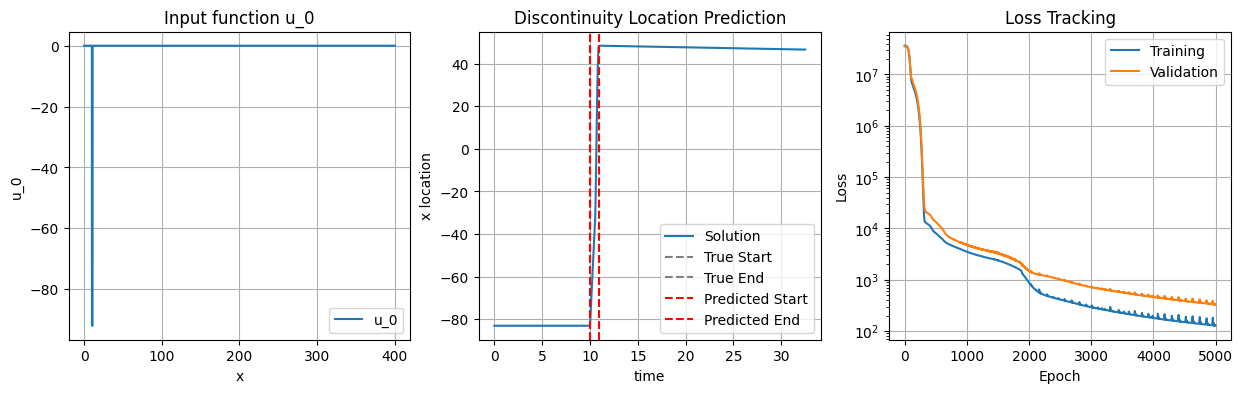

In [ ]:
checkpoint_path = "checkpoints/cutting_net_checkpoint.pt"
checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
model.eval()

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}, trainable parameters: {trainable_params:,}")

input_data_test, output_data_test, output_data_v_test = input_data[test_idx], output_data[test_idx], output_data_v[test_idx]
show_results(model, checkpoint, input_data_test, output_data_test, t, output_data_v_test)